Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [2]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\Expression_Genes_DESeq.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\DEA_Genes_DESeq.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\Clinical_Data_Xiang20.csv"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [3]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
expression_df.head()

,Gene,Mut_D0,Mut_D10,Mut_D18,Mut_D32,Mut_D46,Mut_D74,WT_D0,WT_D10,WT_D18,WT_D32,WT_D46,WT_D74
0,DDX11L2,0,2,4,0,0,0,0,6,2,0,0,4
1,WASH7P,58,134,109,65,107,94,54,103,95,108,162,170
2,MIR1302-2HG,1,4,0,6,1,9,0,0,4,1,2,0
3,ENSG00000238009,22,17,4,22,2,11,17,0,8,15,7,16
4,ENSG00000268903,9,8,15,1,5,4,13,5,8,12,38,31


DEA - Import

In [4]:
dea_df = pd.read_csv(DEA_FILE)
dea_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,RPS4Y1,1727.258166,-8.333990,0.492486,-16.922276,3.082840e-64,7.606290e-60
1,TPTE2P4,640.625385,8.784530,0.633399,13.868877,9.779624e-44,1.206463e-39
2,ZNF681,402.296814,-8.981209,0.713694,-12.584118,2.582104e-36,2.123609e-32
3,DUXAP10,134.909905,5.650007,0.601739,9.389464,6.030661e-21,3.719862e-17
4,CRYZ,391.895815,-12.020684,1.291127,-9.310225,1.275616e-20,6.294656e-17


Volcano plot

Classification
Non-significant    24621
Down-regulated        26
Up-regulated          26
Name: count, dtype: int64
Total tes:
25702


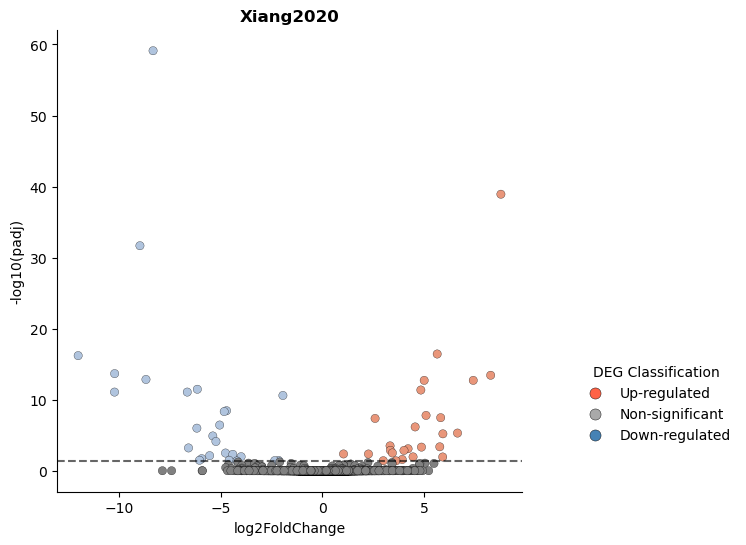

In [5]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0  and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Xiang2020', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    significant_df = dea_df[dea_df['Classification'] != 'Non-significant']
    top_up = significant_df.nlargest(5, 'log2FoldChange')['Gene'].tolist()
    top_down = significant_df.nsmallest(5, 'log2FoldChange')['Gene'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['Gene'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['Gene'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['Gene'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DEG Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação
    print(dea_df['Classification'].value_counts())
    print('Total tes:')
    print(len(expression_df))

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False)
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [6]:
# Variables
genes = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA)

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
print(log2cpm_df.head())

# Process clinical data
clinical_data = clinical_data[['Sample_Name', 'Condition', 'Run', 'Time']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

pca_df.head()




     Mut_D0   Mut_D10   Mut_D18   Mut_D32   Mut_D46   Mut_D74     WT_D0  \
0  0.000000  0.055972  0.149265  0.000000  0.000000  0.000000  0.000000   
1  1.232077  1.868086  1.989274  1.157200  1.789935  1.752814  1.072995   
2  0.033172  0.109854  0.000000  0.155180  0.032767  0.295052  0.000000   
3  0.596180  0.418195  0.149265  0.502218  0.064805  0.353163  0.430276   
4  0.274214  0.211931  0.494433  0.027050  0.156862  0.138628  0.339968   

    WT_D10     WT_D18    WT_D32    WT_D46    WT_D74  
0  0.210884  0.058225  0.000000  0.000000  0.107639  
1  1.888300  1.563766  1.676385  1.806594  2.101713  
2  0.000000  0.114191  0.029044  0.043822  0.000000  
3  0.000000  0.220004  0.384090  0.147886  0.389405  
4  0.177809  0.220004  0.315020  0.665381  0.678378  


,Sample_Name,PC1,PC2,Condition,Run,Time
0,Mut_D0,-146.767696,-85.221632,MECP2_mutant,SRR7551512,D0
1,Mut_D10,-59.096374,141.140590,MECP2_mutant,SRR7551514,D10
2,Mut_D18,-29.099107,83.401093,MECP2_mutant,SRR7551516,D18
3,Mut_D32,77.875441,-15.357311,MECP2_mutant,SRR7551518,D32
4,Mut_D46,87.361567,-56.552115,MECP2_mutant,SRR7551520,D46


PCA - Graph

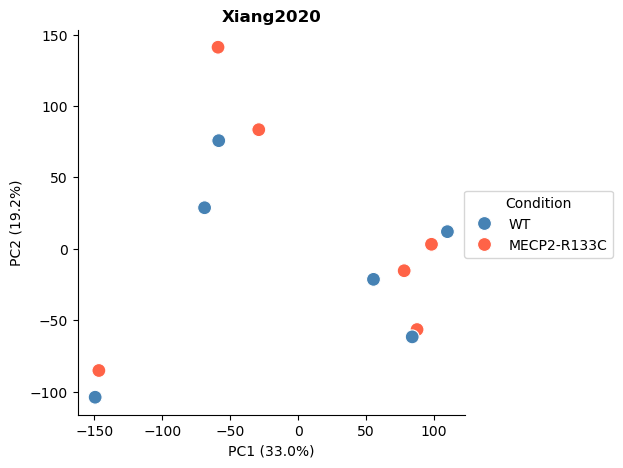

In [13]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'MECP2-R133C' : 'tomato',
               'WT' : 'steelblue'}

pca_df["Condition"] = pca_df["Condition"].replace({"MECP2_mutant": "MECP2-R133C"})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'Condition', s = 100, hue_order = ["WT", "MECP2-R133C"])
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Xiang2020", fontweight = 'bold', fontsize = 12)

ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

In [8]:
# Assemble the new table
log2cpm_df.insert(0, 'Gene', genes)
goi_df = log2cpm_df[log2cpm_df['Gene'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'Gene', var_name = 'Sample_Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'MECP2_mutant' : 'tomato',
                   'WT' : 'steelblue'}

sns.boxplot(data = long_df, x = 'Gene', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - Genes - Xiang', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Genes')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)



TypeError: only list-like objects are allowed to be passed to isin(), you passed a `NoneType`